<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/BCC_Fe_Spin_Resolved_Using_Cupy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Spin-resolved bcc Fe bands and DOS with CuPy

This script uses a nonorthogonal Fe 4s+3d Slater-Koster model, self-consistent Stoner magnetism, primitive-cell Brillouin-zone sampling, and GPU-batched generalized eigensolvers.


In [1]:
!uv pip install cupy-cuda12x numpy scipy matplotlib

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 209ms



=== bcc Fe electronic-structure model ===
Backend: CuPy/CUDA
Basis: one Fe 4s orbital plus five Fe 3d orbitals per atom, nonorthogonal
Lattice constant: 2.8660 angstrom
Stoner I: 0.05500 Ry = 0.7483 eV
Primitive real-space blocks: 58
AFM-cell real-space blocks: 116

Constrained NM diagnostics
  Absolute E_F: +1.008405 eV
  Fe d moments: [+0.00000] mu_B
  Fe total moments: [+0.00000] mu_B
  DOS state integral in plotted window: up=6.0000, down=6.0000


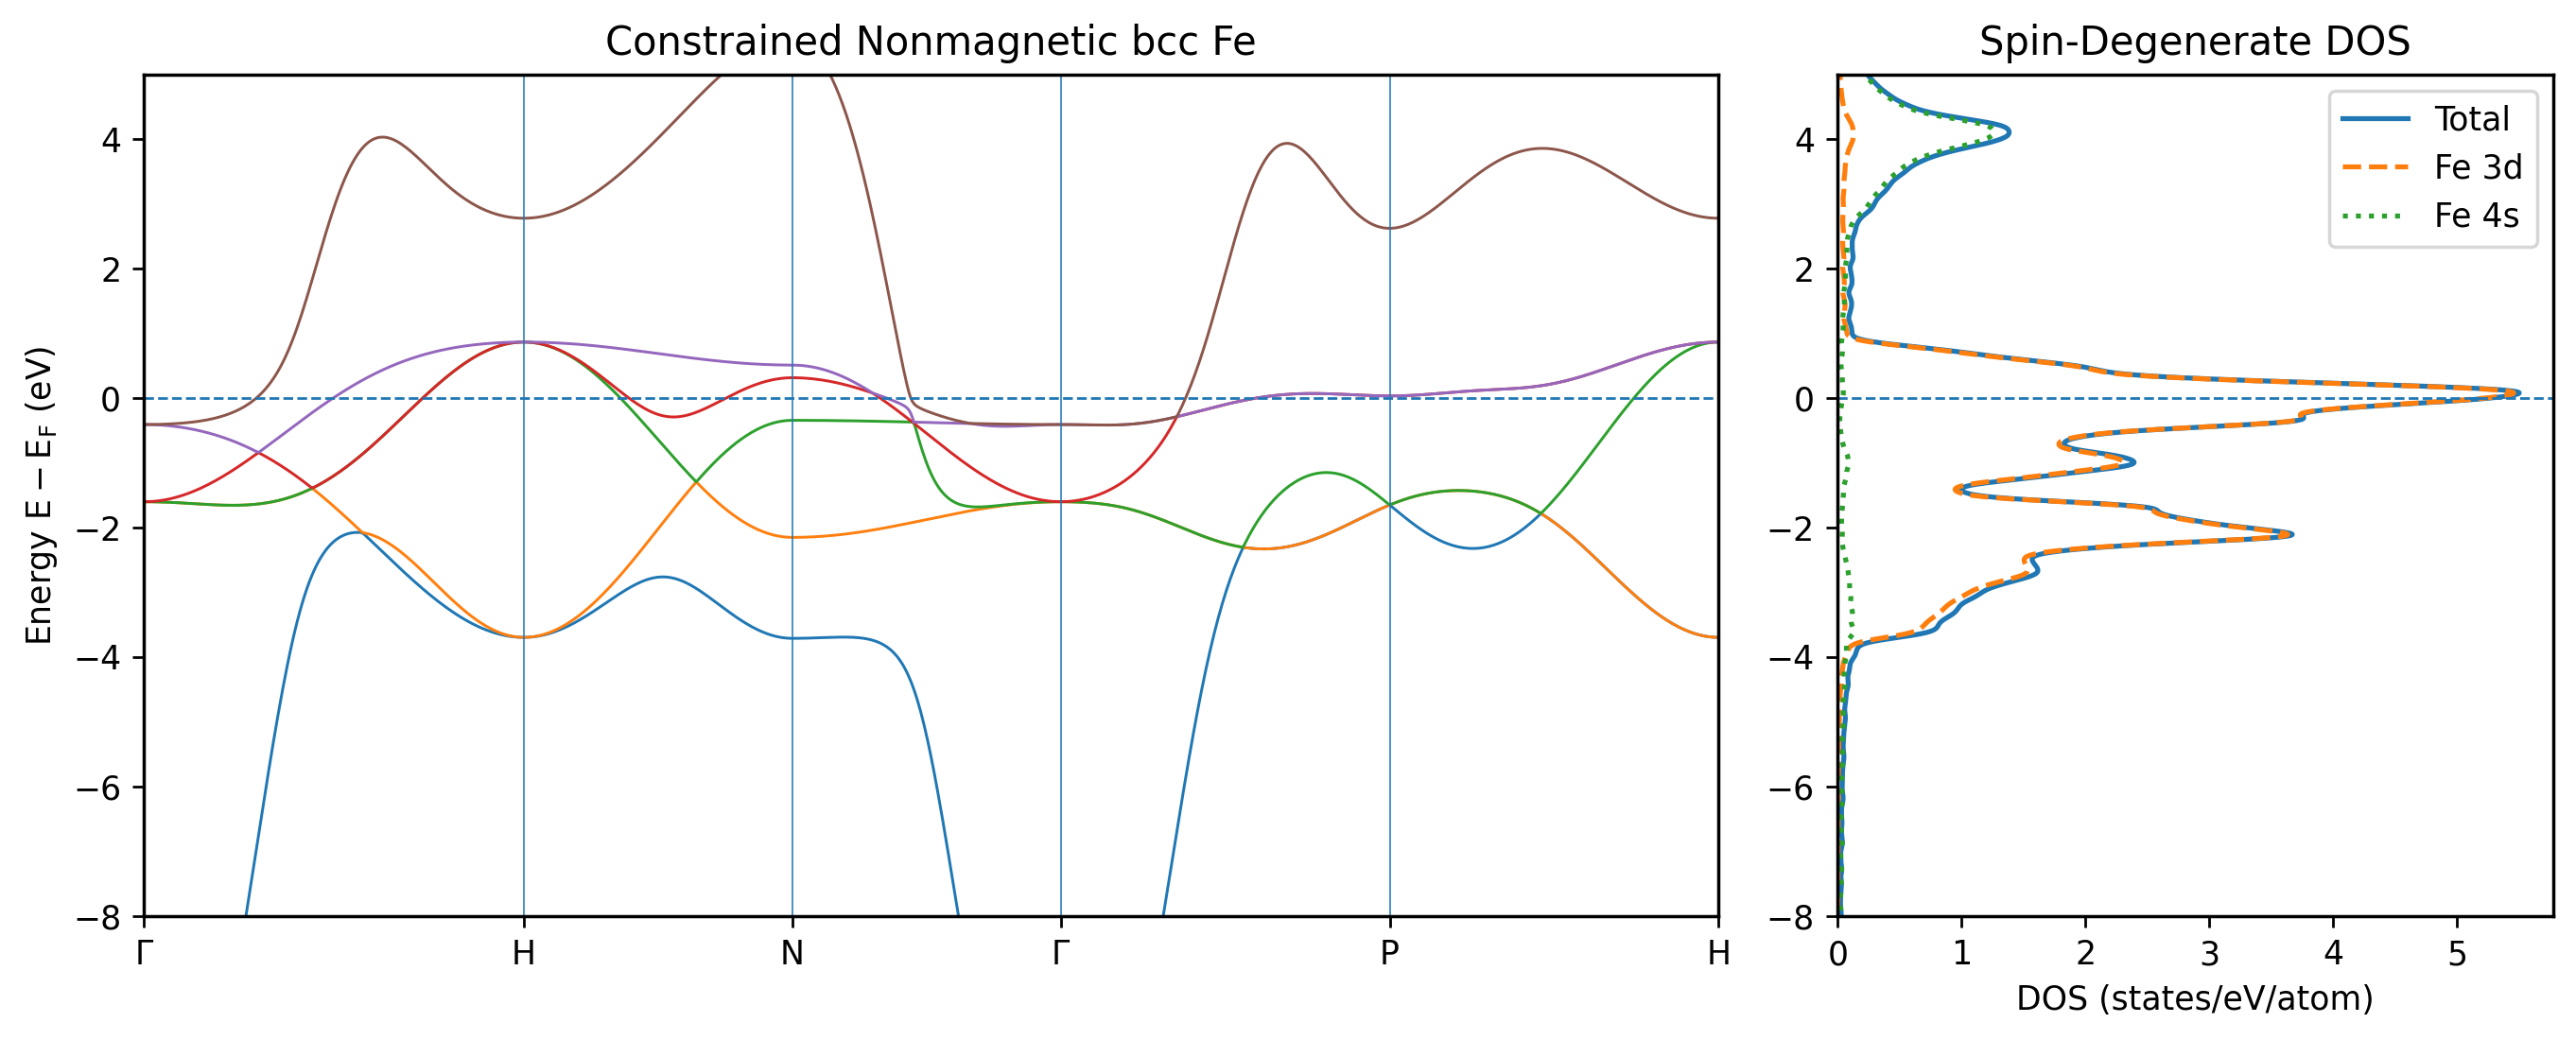

FM SCF   1: m_d = [+2.23039] mu_B, E_F = +1.170663 eV, fixed-point residual = 8.683e-02 mu_B
FM SCF   5: m_d = [+2.29786] mu_B, E_F = +1.201976 eV, fixed-point residual = 5.560e-09 mu_B

FM diagnostics
  Absolute E_F: +1.201976 eV
  Fe d moments: [+2.29786] mu_B
  Fe total moments: [+2.25667] mu_B
  DOS state integral in plotted window: up=6.0000, down=6.0000
  Deviation from 2.22 mu_B reference: 1.65%


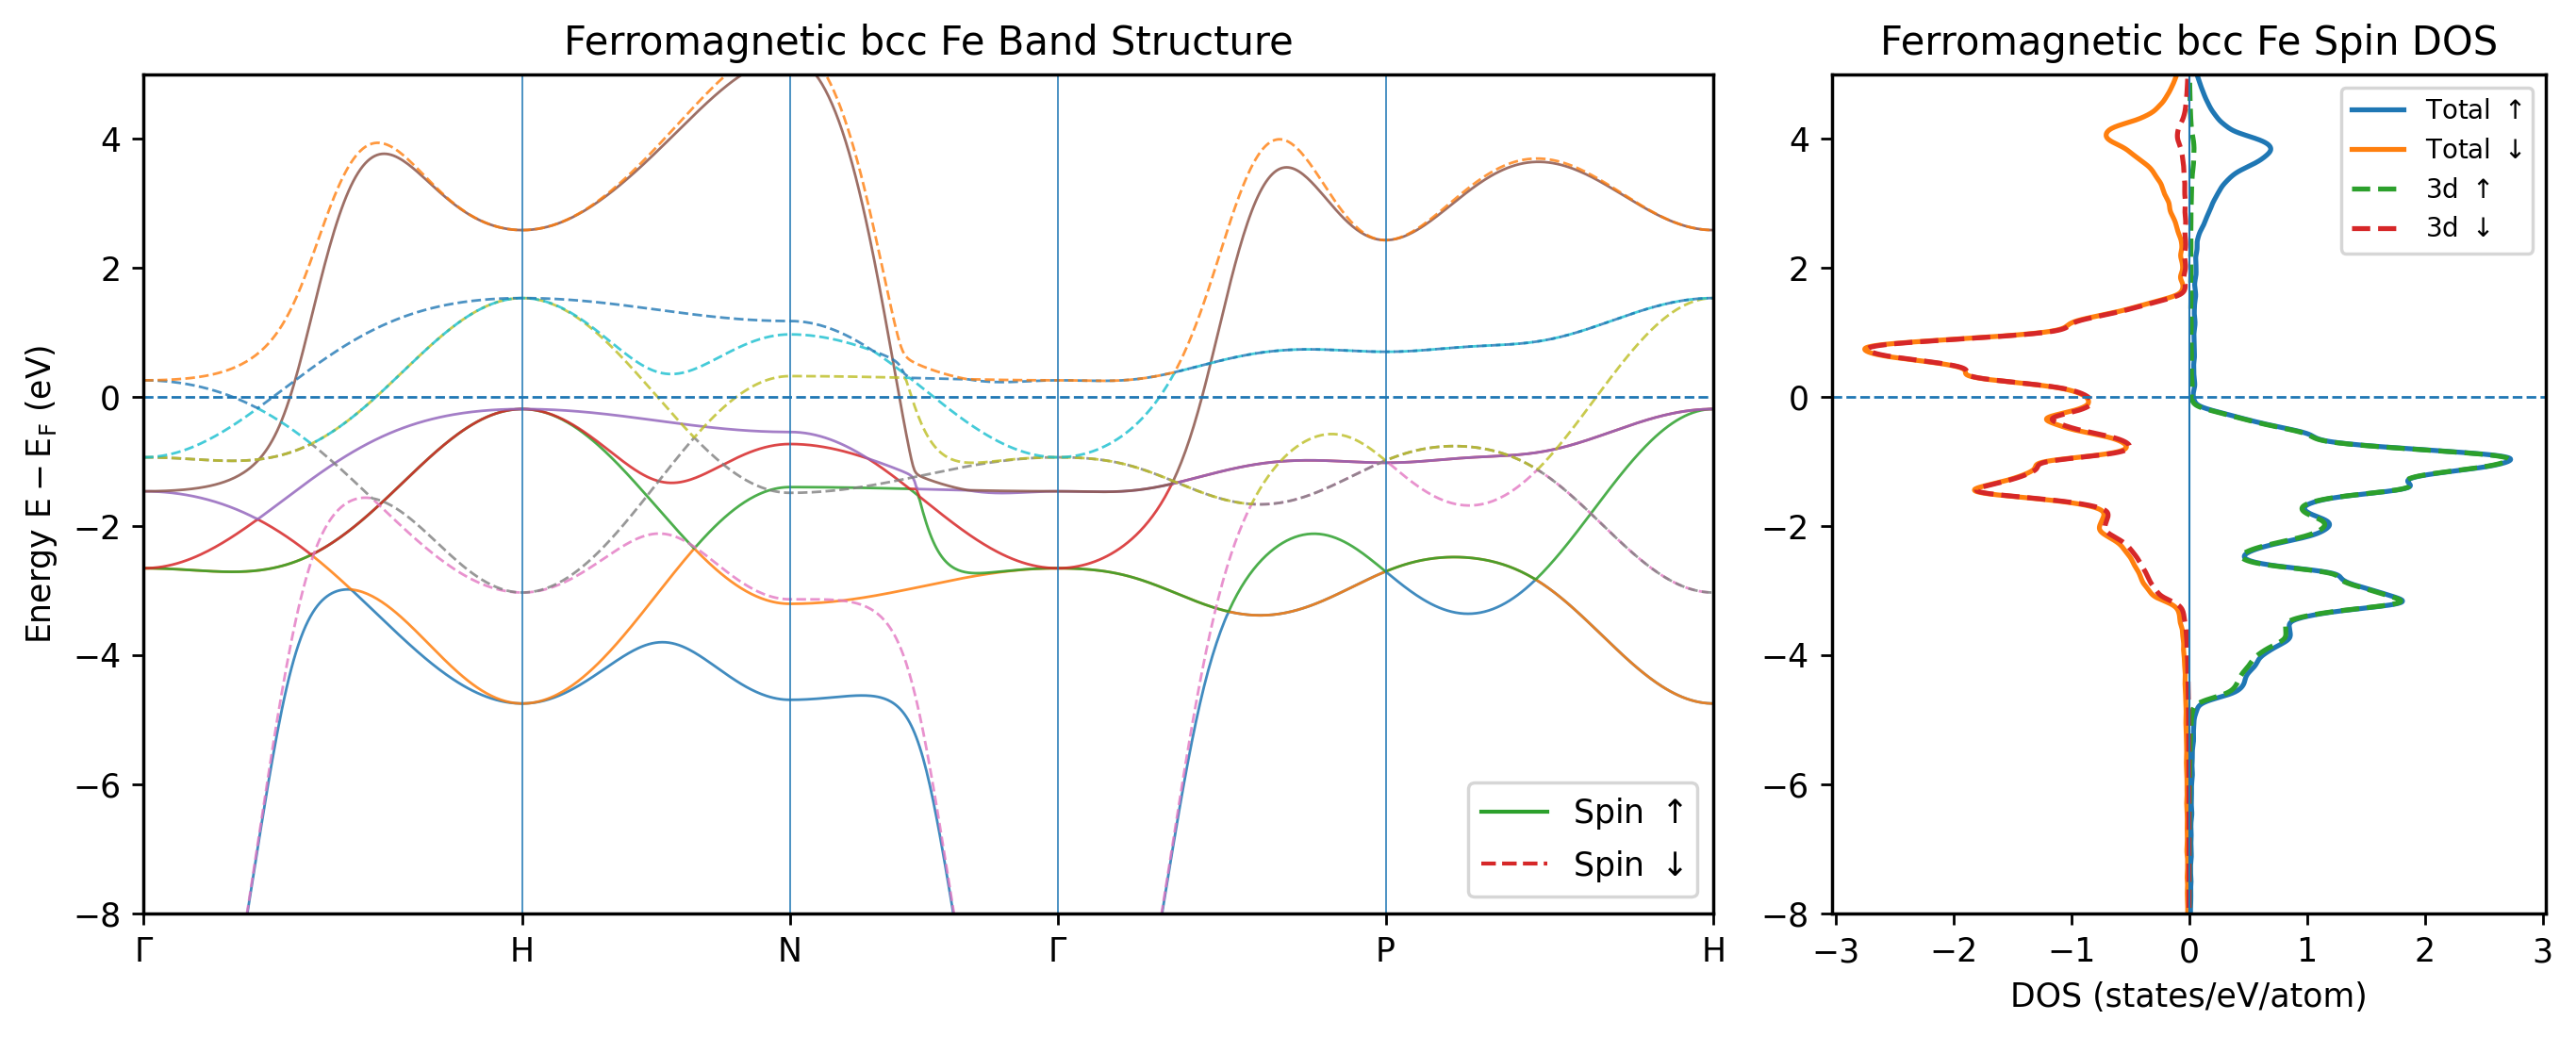

AFM SCF   1: m_d = [+1.69230, -1.69230] mu_B, E_F = +1.184622 eV, fixed-point residual = 3.077e-01 mu_B
AFM SCF   5: m_d = [+0.73671, -0.73671] mu_B, E_F = +1.036466 eV, fixed-point residual = 7.994e-03 mu_B
AFM SCF   8: m_d = [+0.71937, -0.71937] mu_B, E_F = +1.030962 eV, fixed-point residual = 4.693e-06 mu_B

AFM diagnostics
  Absolute E_F: +1.030959 eV
  Fe d moments: [+0.71937, -0.71937] mu_B
  Fe total moments: [+0.72343, -0.72343] mu_B
  DOS state integral in plotted window: up=6.0000, down=6.0000


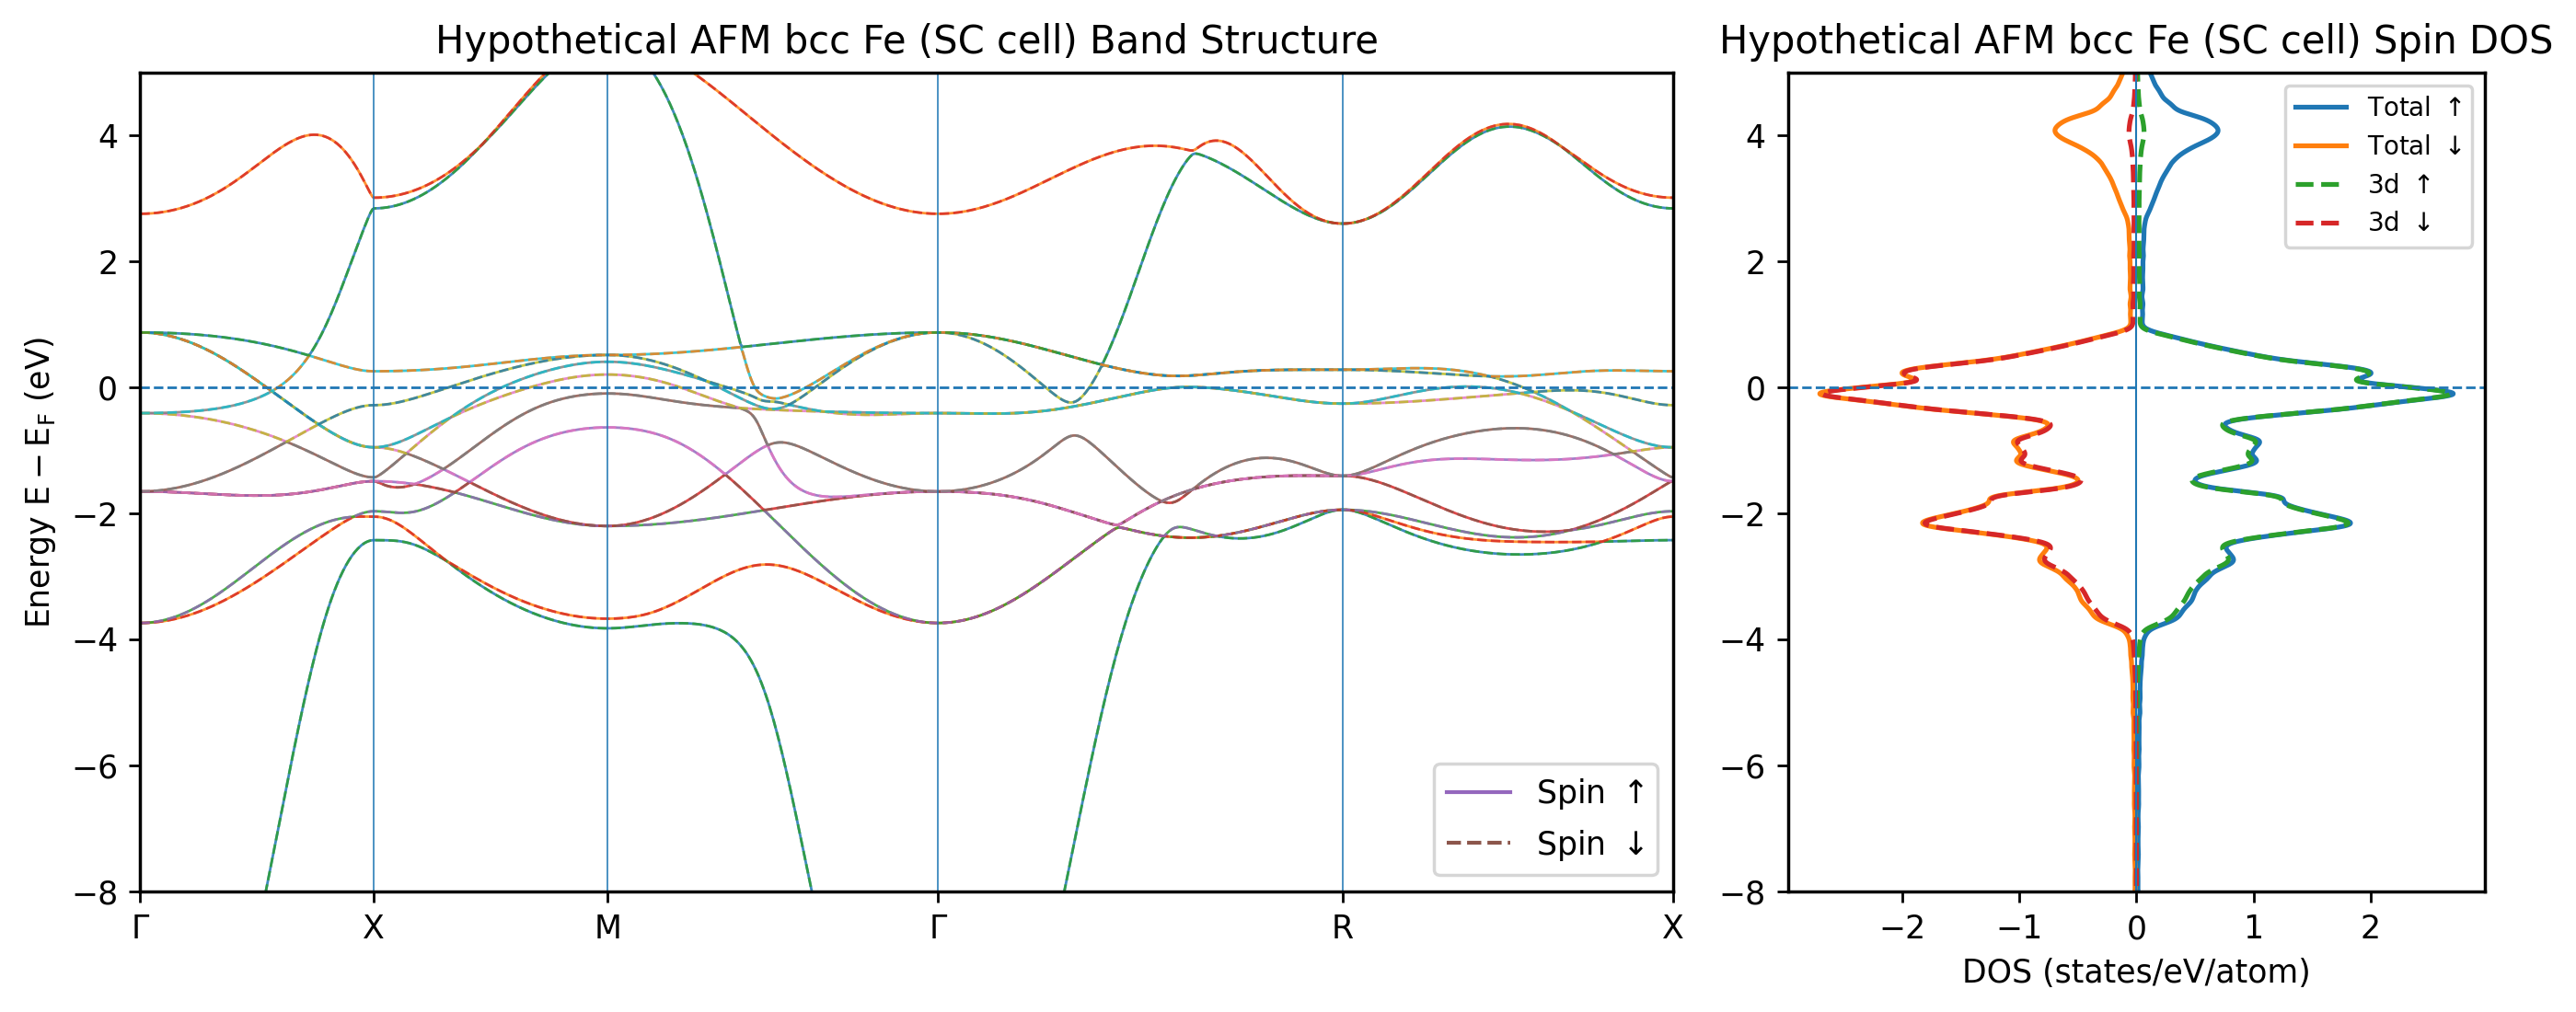

In [2]:
"""GPU-accelerated spin-resolved electronic-structure model for bcc iron.

This script replaces a single-band toy dispersion with a published,
nonorthogonal six-orbital Slater-Koster model containing one Fe 4s orbital and
five Fe 3d orbitals per atom. Collinear magnetism is treated with a
self-consistent Stoner field. The generalized eigenproblem H(k)c = E S(k)c is
solved in batches using a Lowdin transformation, with CuPy providing GPU
acceleration when a CUDA device is available.

The model is suitable for physically informed band-structure and DOS studies.
Quantitative publication-grade results should be checked against a converged
all-electron or plane-wave DFT calculation.
"""

import itertools
import math
from dataclasses import dataclass
from typing import Any, Iterable, Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# CONTROL KNOBS
# =============================================================================

# Crystal and electron count.
LATTICE_CONSTANT_ANGSTROM: float = 2.866
VALENCE_ELECTRONS_PER_FE: float = 8.0
REFERENCE_MOMENT_MU_B: float = 2.22

# Published nonorthogonal s-d tight-binding parameters for Fe.
# Energies are in Rydbergs, distances in bohr, and q in bohr^{-1}.
S_ONSITE_MINUS_D_ONSITE_RY: float = 0.15
STONER_I_RY: float = 0.055

# Self-consistent magnetic calculation.
ELECTRON_TEMPERATURE_K: float = 1000.0
SCF_MIXING: float = 0.35
SCF_TOLERANCE_MU_B: float = 2.0e-5
SCF_MAX_ITERATIONS: int = 100
SCF_USE_SECANT_ACCELERATION: bool = True
SCF_MAX_SECANT_STEP_MU_B: float = 1.0
FM_INITIAL_MOMENT_MU_B: float = 2.20
AFM_INITIAL_MOMENT_MU_B: float = 1.80
FM_SCF_K_MESH: tuple[int, int, int] = (28, 28, 28)
AFM_SCF_K_MESH: tuple[int, int, int] = (22, 22, 22)

# Brillouin-zone integration and band paths.
DOS_K_MESH_PRIMITIVE: tuple[int, int, int] = (64, 64, 64)
DOS_K_MESH_AFM: tuple[int, int, int] = (48, 48, 48)
BAND_POINTS_PER_SEGMENT: int = 160
USE_SHIFTED_MONKHORST_PACK: bool = True

# DOS construction. The histogram is evaluated on the GPU and broadened using
# cupyx.scipy.ndimage.gaussian_filter1d.
DOS_ENERGY_MIN_EV: float = -16.0
DOS_ENERGY_MAX_EV: float = 8.0
DOS_NUMBER_OF_BINS: int = 3600
DOS_GAUSSIAN_SIGMA_EV: float = 0.065

# Numerical precision and GPU memory use.
EIGENSOLVER_BATCH_SIZE_PRIMITIVE: int = 16384
EIGENSOLVER_BATCH_SIZE_AFM: int = 4096
OVERLAP_EIGENVALUE_FLOOR: float = 1.0e-9
FERMI_BISECTION_ITERATIONS: int = 64

# Plots and diagnostics.
PLOT_DPI: int = 250
PLOT_ENERGY_MIN_EV: float = -8.0
PLOT_ENERGY_MAX_EV: float = 5.0
SHOW_ORBITAL_PROJECTED_DOS: bool = True
RUN_K_MESH_CONVERGENCE_STUDY: bool = False
CONVERGENCE_MESHES: tuple[int, ...] = (12, 16, 20, 24, 28)
VERBOSE_SCF: bool = True

# =============================================================================
# PHYSICAL CONSTANTS
# =============================================================================

BOHR_ANGSTROM: float = 0.529177210903
RYDBERG_EV: float = 13.605693122994
BOLTZMANN_EV_PER_K: float = 8.617333262145e-5
BOLTZMANN_RY_PER_K: float = BOLTZMANN_EV_PER_K / RYDBERG_EV
ORBITALS_PER_FE: int = 6
D_ORBITAL_OFFSET: int = 1

# =============================================================================
# RENDERING PREFERENCES
# =============================================================================

mpl.rcParams["figure.dpi"] = PLOT_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["axes.linewidth"] = 1.0
mpl.rcParams["mathtext.default"] = "regular"

# =============================================================================
# ARRAY BACKEND
# =============================================================================

try:
    import cupy as xp
    from cupyx.scipy.ndimage import gaussian_filter1d

    if xp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("No CUDA device is visible to CuPy.")
    USING_CUPY = True
except (ImportError, RuntimeError):
    import numpy as xp
    from scipy.ndimage import gaussian_filter1d

    USING_CUPY = False


# =============================================================================
# MODEL PARAMETERS AND DATA CLASSES
# =============================================================================


@dataclass(frozen=True)
class RadialIntegral:
    """Distance-dependent Slater-Koster integral."""

    amplitude_ry: float
    decay_bohr_inverse: float
    smooth_start_in_lattice_constants: float
    cutoff_in_lattice_constants: float


RADIAL_PARAMETERS: dict[str, RadialIntegral] = {
    "dd_sigma": RadialIntegral(-2.438, 0.9, 1.1, 1.4),
    "dd_pi": RadialIntegral(1.997, 0.9, 1.1, 1.4),
    "dd_delta": RadialIntegral(-0.907, 0.9, 1.1, 1.4),
    "sd_sigma": RadialIntegral(-0.141, 0.3, 1.1, 2.0),
    "ss_sigma": RadialIntegral(-0.350, 0.3, 1.1, 2.0),
    "sd_overlap": RadialIntegral(0.50, 0.6, 1.1, 2.0),
    "ss_overlap": RadialIntegral(0.45, 0.5, 1.1, 2.0),
}


@dataclass(frozen=True)
class PeriodicModel:
    """CPU-side representation of a periodic nonorthogonal TB model."""

    name: str
    direct_lattice_angstrom: np.ndarray
    reciprocal_lattice_inverse_angstrom: np.ndarray
    basis_positions_angstrom: np.ndarray
    displacement_vectors_angstrom: np.ndarray
    hopping_terms_ry: np.ndarray
    overlap_terms: np.ndarray
    onsite_hamiltonian_ry: np.ndarray
    onsite_overlap: np.ndarray
    number_of_atoms: int
    number_of_orbitals: int


@dataclass(frozen=True)
class DeviceModel:
    """Device-side arrays used by the batched eigensolver."""

    source: PeriodicModel
    displacement_vectors_angstrom: Any
    hopping_terms_ry: Any
    overlap_terms: Any
    onsite_hamiltonian_ry: Any
    onsite_overlap: Any


@dataclass(frozen=True)
class ScfResult:
    """Converged collinear magnetic solution."""

    phase_name: str
    d_moments_mu_b: np.ndarray
    total_moments_mu_b: np.ndarray
    fermi_energy_ry: float
    iterations: int
    converged: bool


@dataclass(frozen=True)
class BandPath:
    """High-symmetry reciprocal-space path."""

    k_points_inverse_angstrom: np.ndarray
    cumulative_distance_inverse_angstrom: np.ndarray
    tick_positions_inverse_angstrom: np.ndarray
    tick_labels: tuple[str, ...]


@dataclass(frozen=True)
class DosResult:
    """Spin-resolved DOS and orbital projections."""

    energy_ev: np.ndarray
    total_spin_up: np.ndarray
    total_spin_down: np.ndarray
    d_spin_up: np.ndarray
    d_spin_down: np.ndarray
    s_spin_up: np.ndarray
    s_spin_down: np.ndarray


# =============================================================================
# SMALL BACKEND HELPERS
# =============================================================================


def to_numpy(array: Any) -> np.ndarray:
    """Transfers an array to host memory."""
    if USING_CUPY:
        return xp.asnumpy(array)
    return np.asarray(array)


def device_scalar(value: Any) -> float:
    """Converts a scalar on either backend to a Python float."""
    if USING_CUPY:
        return float(value.get())
    return float(value)


def synchronize_device() -> None:
    """Synchronizes the current CUDA stream when CuPy is active."""
    if USING_CUPY:
        xp.cuda.get_current_stream().synchronize()


# =============================================================================
# SLATER-KOSTER CONSTRUCTION
# =============================================================================


def normalized_real_d_matrices() -> np.ndarray:
    """Returns an orthonormal real-cubic d-orbital tensor basis.

    The order is d_xy, d_yz, d_zx, d_(x2-y2), d_(3z2-r2). A quadratic
    orbital is represented by r.T @ Q @ r with Tr(Q_i Q_j) = delta_ij.
    """
    matrices: list[np.ndarray] = []

    d_xy = np.zeros((3, 3), dtype=np.float64)
    d_xy[0, 1] = d_xy[1, 0] = 1.0 / math.sqrt(2.0)
    matrices.append(d_xy)

    d_yz = np.zeros((3, 3), dtype=np.float64)
    d_yz[1, 2] = d_yz[2, 1] = 1.0 / math.sqrt(2.0)
    matrices.append(d_yz)

    d_zx = np.zeros((3, 3), dtype=np.float64)
    d_zx[2, 0] = d_zx[0, 2] = 1.0 / math.sqrt(2.0)
    matrices.append(d_zx)

    matrices.append(np.diag([1.0, -1.0, 0.0]) / math.sqrt(2.0))
    matrices.append(np.diag([-1.0, -1.0, 2.0]) / math.sqrt(6.0))
    return np.asarray(matrices)


REAL_D_MATRICES: np.ndarray = normalized_real_d_matrices()


def bond_frame(direction: np.ndarray) -> np.ndarray:
    """Builds a right-handed local coordinate frame with local z along a bond."""
    local_z = direction / np.linalg.norm(direction)
    reference = np.asarray([0.0, 0.0, 1.0])
    if abs(float(np.dot(reference, local_z))) > 0.90:
        reference = np.asarray([0.0, 1.0, 0.0])

    local_x = np.cross(reference, local_z)
    local_x /= np.linalg.norm(local_x)
    local_y = np.cross(local_z, local_x)
    return np.column_stack((local_x, local_y, local_z))


def d_orbital_rotation(direction: np.ndarray) -> np.ndarray:
    """Returns the real d-orbital rotation matrix for a bond direction."""
    rotation = bond_frame(direction)
    rotated_matrices = np.einsum(
        "ab,jbc,dc->jad",
        rotation,
        REAL_D_MATRICES,
        rotation,
        optimize=True,
    )
    representation = np.einsum(
        "iab,jab->ij",
        REAL_D_MATRICES,
        rotated_matrices,
        optimize=True,
    )
    return representation


def quintic_tail_coefficients(
    value_at_start: float,
    first_derivative_x: float,
    second_derivative_x: float,
) -> np.ndarray:
    """Builds a C2 quintic polynomial that reaches zero at x = 1."""
    a0 = value_at_start
    a1 = first_derivative_x
    a2 = 0.5 * second_derivative_x

    matrix = np.asarray(
        [
            [1.0, 1.0, 1.0],
            [3.0, 4.0, 5.0],
            [6.0, 12.0, 20.0],
        ]
    )
    right_hand_side = np.asarray(
        [
            -(a0 + a1 + a2),
            -(a1 + 2.0 * a2),
            -2.0 * a2,
        ]
    )
    a3, a4, a5 = np.linalg.solve(matrix, right_hand_side)
    return np.asarray([a0, a1, a2, a3, a4, a5])


def evaluate_radial_integral(
    parameter: RadialIntegral,
    distance_angstrom: float,
) -> float:
    """Evaluates an exponential integral with a smooth finite-range cutoff."""
    distance_bohr = distance_angstrom / BOHR_ANGSTROM
    lattice_bohr = LATTICE_CONSTANT_ANGSTROM / BOHR_ANGSTROM
    smooth_start_bohr = (
        parameter.smooth_start_in_lattice_constants * lattice_bohr
    )
    cutoff_bohr = parameter.cutoff_in_lattice_constants * lattice_bohr

    if distance_bohr >= cutoff_bohr:
        return 0.0

    exponential_value = parameter.amplitude_ry * math.exp(
        -parameter.decay_bohr_inverse * distance_bohr
    )
    if distance_bohr <= smooth_start_bohr:
        return exponential_value

    interval_bohr = cutoff_bohr - smooth_start_bohr
    value_at_start = parameter.amplitude_ry * math.exp(
        -parameter.decay_bohr_inverse * smooth_start_bohr
    )
    derivative_x = (
        -parameter.decay_bohr_inverse * interval_bohr * value_at_start
    )
    second_derivative_x = (
        parameter.decay_bohr_inverse * interval_bohr
    ) ** 2 * value_at_start
    coefficients = quintic_tail_coefficients(
        value_at_start,
        derivative_x,
        second_derivative_x,
    )
    x_value = (distance_bohr - smooth_start_bohr) / interval_bohr
    powers = np.asarray([x_value**power for power in range(6)])
    return float(np.dot(coefficients, powers))


def slater_koster_sd_block(
    displacement_angstrom: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Builds a 6 x 6 Fe-Fe Hamiltonian and overlap block."""
    distance = float(np.linalg.norm(displacement_angstrom))
    direction = displacement_angstrom / distance
    d_rotation = d_orbital_rotation(direction)

    dd_local = np.diag(
        [
            evaluate_radial_integral(RADIAL_PARAMETERS["dd_delta"], distance),
            evaluate_radial_integral(RADIAL_PARAMETERS["dd_pi"], distance),
            evaluate_radial_integral(RADIAL_PARAMETERS["dd_pi"], distance),
            evaluate_radial_integral(RADIAL_PARAMETERS["dd_delta"], distance),
            evaluate_radial_integral(RADIAL_PARAMETERS["dd_sigma"], distance),
        ]
    )
    dd_global = d_rotation @ dd_local @ d_rotation.T
    local_d_z2_in_global_basis = d_rotation[:, 4]

    hamiltonian = np.zeros(
        (ORBITALS_PER_FE, ORBITALS_PER_FE), dtype=np.float64
    )
    overlap = np.zeros_like(hamiltonian)

    hamiltonian[0, 0] = evaluate_radial_integral(
        RADIAL_PARAMETERS["ss_sigma"], distance
    )
    sd_hopping = evaluate_radial_integral(
        RADIAL_PARAMETERS["sd_sigma"], distance
    )
    hamiltonian[0, 1:] = sd_hopping * local_d_z2_in_global_basis
    hamiltonian[1:, 0] = hamiltonian[0, 1:]
    hamiltonian[1:, 1:] = dd_global

    overlap[0, 0] = evaluate_radial_integral(
        RADIAL_PARAMETERS["ss_overlap"], distance
    )
    sd_overlap = evaluate_radial_integral(
        RADIAL_PARAMETERS["sd_overlap"], distance
    )
    overlap[0, 1:] = sd_overlap * local_d_z2_in_global_basis
    overlap[1:, 0] = overlap[0, 1:]
    return hamiltonian, overlap


def reciprocal_lattice(direct_lattice_angstrom: np.ndarray) -> np.ndarray:
    """Returns row-vector reciprocal lattice vectors in inverse angstroms."""
    return 2.0 * np.pi * np.linalg.inv(direct_lattice_angstrom).T


def translation_search_radius(
    direct_lattice_angstrom: np.ndarray,
    basis_positions_angstrom: np.ndarray,
    maximum_cutoff_angstrom: float,
) -> int:
    """Selects a conservative integer translation bound."""
    minimum_singular_value = float(
        np.linalg.svd(direct_lattice_angstrom, compute_uv=False).min()
    )
    maximum_basis_separation = max(
        float(np.linalg.norm(position_a - position_b))
        for position_a in basis_positions_angstrom
        for position_b in basis_positions_angstrom
    )
    return (
        math.ceil(
            (maximum_cutoff_angstrom + maximum_basis_separation)
            / minimum_singular_value
        )
        + 2
    )


def build_periodic_model(
    name: str,
    direct_lattice_angstrom: np.ndarray,
    basis_positions_angstrom: np.ndarray,
) -> PeriodicModel:
    """Builds all real-space blocks required by a periodic TB model."""
    direct_lattice_angstrom = np.asarray(
        direct_lattice_angstrom, dtype=np.float64
    )
    basis_positions_angstrom = np.asarray(
        basis_positions_angstrom, dtype=np.float64
    )
    number_of_atoms = basis_positions_angstrom.shape[0]
    number_of_orbitals = ORBITALS_PER_FE * number_of_atoms

    maximum_cutoff = max(
        parameter.cutoff_in_lattice_constants
        for parameter in RADIAL_PARAMETERS.values()
    ) * LATTICE_CONSTANT_ANGSTROM
    search_radius = translation_search_radius(
        direct_lattice_angstrom,
        basis_positions_angstrom,
        maximum_cutoff,
    )

    displacement_vectors: list[np.ndarray] = []
    hopping_terms: list[np.ndarray] = []
    overlap_terms: list[np.ndarray] = []

    integer_range = range(-search_radius, search_radius + 1)
    for atom_i, atom_j in itertools.product(
        range(number_of_atoms), repeat=2
    ):
        for translation_indices in itertools.product(integer_range, repeat=3):
            if atom_i == atom_j and translation_indices == (0, 0, 0):
                continue

            translation = (
                np.asarray(translation_indices, dtype=np.float64)
                @ direct_lattice_angstrom
            )
            displacement = (
                translation
                + basis_positions_angstrom[atom_j]
                - basis_positions_angstrom[atom_i]
            )
            distance = float(np.linalg.norm(displacement))
            if distance <= 1.0e-10 or distance >= maximum_cutoff:
                continue

            local_hamiltonian, local_overlap = slater_koster_sd_block(
                displacement
            )
            if (
                np.max(np.abs(local_hamiltonian))
                + np.max(np.abs(local_overlap))
                < 1.0e-14
            ):
                continue

            full_hamiltonian = np.zeros(
                (number_of_orbitals, number_of_orbitals), dtype=np.float64
            )
            full_overlap = np.zeros_like(full_hamiltonian)
            row_slice = slice(
                atom_i * ORBITALS_PER_FE,
                (atom_i + 1) * ORBITALS_PER_FE,
            )
            column_slice = slice(
                atom_j * ORBITALS_PER_FE,
                (atom_j + 1) * ORBITALS_PER_FE,
            )
            full_hamiltonian[row_slice, column_slice] = local_hamiltonian
            full_overlap[row_slice, column_slice] = local_overlap

            displacement_vectors.append(displacement)
            hopping_terms.append(full_hamiltonian)
            overlap_terms.append(full_overlap)

    onsite_hamiltonian = np.zeros(
        (number_of_orbitals, number_of_orbitals), dtype=np.float64
    )
    onsite_overlap = np.eye(number_of_orbitals, dtype=np.float64)
    for atom_index in range(number_of_atoms):
        s_index = atom_index * ORBITALS_PER_FE
        onsite_hamiltonian[s_index, s_index] = S_ONSITE_MINUS_D_ONSITE_RY

    return PeriodicModel(
        name=name,
        direct_lattice_angstrom=direct_lattice_angstrom,
        reciprocal_lattice_inverse_angstrom=reciprocal_lattice(
            direct_lattice_angstrom
        ),
        basis_positions_angstrom=basis_positions_angstrom,
        displacement_vectors_angstrom=np.asarray(displacement_vectors),
        hopping_terms_ry=np.asarray(hopping_terms),
        overlap_terms=np.asarray(overlap_terms),
        onsite_hamiltonian_ry=onsite_hamiltonian,
        onsite_overlap=onsite_overlap,
        number_of_atoms=number_of_atoms,
        number_of_orbitals=number_of_orbitals,
    )


def build_bcc_primitive_model() -> PeriodicModel:
    """Builds the one-atom primitive bcc Fe model."""
    half_lattice = 0.5 * LATTICE_CONSTANT_ANGSTROM
    direct_lattice = half_lattice * np.asarray(
        [
            [-1.0, 1.0, 1.0],
            [1.0, -1.0, 1.0],
            [1.0, 1.0, -1.0],
        ]
    )
    return build_periodic_model(
        "bcc primitive",
        direct_lattice,
        np.asarray([[0.0, 0.0, 0.0]]),
    )


def build_bcc_afm_model() -> PeriodicModel:
    """Builds a two-sublattice simple-cubic representation of bcc Fe."""
    direct_lattice = LATTICE_CONSTANT_ANGSTROM * np.eye(3)
    basis_positions = np.asarray(
        [
            [0.0, 0.0, 0.0],
            [
                0.5 * LATTICE_CONSTANT_ANGSTROM,
                0.5 * LATTICE_CONSTANT_ANGSTROM,
                0.5 * LATTICE_CONSTANT_ANGSTROM,
            ],
        ]
    )
    return build_periodic_model(
        "bcc two-sublattice AFM cell",
        direct_lattice,
        basis_positions,
    )


def move_model_to_device(model: PeriodicModel) -> DeviceModel:
    """Copies a periodic model to the active array backend."""
    return DeviceModel(
        source=model,
        displacement_vectors_angstrom=xp.asarray(
            model.displacement_vectors_angstrom, dtype=xp.float64
        ),
        hopping_terms_ry=xp.asarray(model.hopping_terms_ry, dtype=xp.float64),
        overlap_terms=xp.asarray(model.overlap_terms, dtype=xp.float64),
        onsite_hamiltonian_ry=xp.asarray(
            model.onsite_hamiltonian_ry, dtype=xp.float64
        ),
        onsite_overlap=xp.asarray(model.onsite_overlap, dtype=xp.float64),
    )


# =============================================================================
# K-POINTS AND GENERALIZED EIGENSOLVER
# =============================================================================


def monkhorst_pack_grid(
    reciprocal_lattice_inverse_angstrom: np.ndarray,
    mesh: Sequence[int],
) -> np.ndarray:
    """Generates a uniform grid over a primitive reciprocal parallelepiped."""
    fractional_axes: list[np.ndarray] = []
    for number_of_points in mesh:
        if USE_SHIFTED_MONKHORST_PACK:
            axis = (
                (np.arange(number_of_points, dtype=np.float64) + 0.5)
                / number_of_points
                - 0.5
            )
        else:
            axis = np.arange(number_of_points, dtype=np.float64) / number_of_points
            axis -= np.floor(axis + 0.5)
        fractional_axes.append(axis)

    fractional_grid = np.stack(
        np.meshgrid(*fractional_axes, indexing="ij"), axis=-1
    ).reshape(-1, 3)
    return fractional_grid @ reciprocal_lattice_inverse_angstrom


def assemble_base_bloch_matrices(
    model: DeviceModel,
    k_points_inverse_angstrom: Any,
) -> tuple[Any, Any]:
    """Assembles spin-independent H(k) and S(k) in a batch."""
    phase = xp.exp(
        1j
        * k_points_inverse_angstrom
        @ model.displacement_vectors_angstrom.T
    )
    hamiltonian = xp.tensordot(
        phase,
        model.hopping_terms_ry,
        axes=((1,), (0,)),
    )
    overlap = xp.tensordot(
        phase,
        model.overlap_terms,
        axes=((1,), (0,)),
    )
    hamiltonian += model.onsite_hamiltonian_ry[None, :, :]
    overlap += model.onsite_overlap[None, :, :]

    hamiltonian = 0.5 * (
        hamiltonian + hamiltonian.conj().transpose(0, 2, 1)
    )
    overlap = 0.5 * (overlap + overlap.conj().transpose(0, 2, 1))
    return hamiltonian, overlap


def stoner_shift_diagonal(
    model: PeriodicModel,
    d_moments_mu_b: np.ndarray,
    spin_sign: int,
) -> Any:
    """Returns the site-resolved Stoner shift for one spin channel."""
    diagonal = np.zeros(model.number_of_orbitals, dtype=np.float64)
    for atom_index, local_moment in enumerate(d_moments_mu_b):
        d_start = atom_index * ORBITALS_PER_FE + D_ORBITAL_OFFSET
        d_stop = (atom_index + 1) * ORBITALS_PER_FE
        diagonal[d_start:d_stop] = (
            -0.5 * spin_sign * STONER_I_RY * local_moment
        )
    return xp.asarray(diagonal, dtype=xp.float64)


def lowdin_factor(overlap: Any) -> tuple[Any, float]:
    """Computes S^{-1/2} for a batch of positive-definite overlap matrices."""
    overlap_eigenvalues, overlap_eigenvectors = xp.linalg.eigh(overlap)
    minimum_overlap = device_scalar(xp.min(overlap_eigenvalues))
    if minimum_overlap <= OVERLAP_EIGENVALUE_FLOOR:
        raise ValueError(
            "The overlap matrix is singular or indefinite. "
            f"Minimum eigenvalue: {minimum_overlap:.3e}."
        )

    inverse_square_roots = 1.0 / xp.sqrt(overlap_eigenvalues)
    scaled_eigenvectors = (
        overlap_eigenvectors * inverse_square_roots[:, None, :]
    )
    inverse_square_root = (
        scaled_eigenvectors
        @ overlap_eigenvectors.conj().transpose(0, 2, 1)
    )
    return inverse_square_root, minimum_overlap


def solve_spin_channel(
    model: DeviceModel,
    base_hamiltonian: Any,
    overlap: Any,
    inverse_overlap_square_root: Any,
    d_moments_mu_b: np.ndarray,
    spin_sign: int,
    return_weights: bool,
) -> tuple[Any, Any | None, Any | None]:
    """Solves one spin channel and optionally computes Mulliken weights."""
    shifted_hamiltonian = base_hamiltonian.copy()
    shift = stoner_shift_diagonal(model.source, d_moments_mu_b, spin_sign)
    diagonal_indices = xp.arange(model.source.number_of_orbitals)
    shifted_hamiltonian[:, diagonal_indices, diagonal_indices] += shift

    orthogonal_hamiltonian = (
        inverse_overlap_square_root
        @ shifted_hamiltonian
        @ inverse_overlap_square_root
    )
    orthogonal_hamiltonian = 0.5 * (
        orthogonal_hamiltonian
        + orthogonal_hamiltonian.conj().transpose(0, 2, 1)
    )

    if not return_weights:
        eigenvalues = xp.linalg.eigvalsh(orthogonal_hamiltonian)
        return eigenvalues, None, None

    eigenvalues, orthogonal_eigenvectors = xp.linalg.eigh(
        orthogonal_hamiltonian
    )
    generalized_eigenvectors = (
        inverse_overlap_square_root @ orthogonal_eigenvectors
    )
    overlap_times_vectors = overlap @ generalized_eigenvectors
    orbital_weights = xp.real(
        generalized_eigenvectors.conj() * overlap_times_vectors
    )

    d_weights_by_atom: list[Any] = []
    total_weights_by_atom: list[Any] = []
    for atom_index in range(model.source.number_of_atoms):
        orbital_start = atom_index * ORBITALS_PER_FE
        orbital_stop = (atom_index + 1) * ORBITALS_PER_FE
        d_weights_by_atom.append(
            xp.sum(
                orbital_weights[
                    :,
                    orbital_start + D_ORBITAL_OFFSET : orbital_stop,
                    :,
                ],
                axis=1,
            )
        )
        total_weights_by_atom.append(
            xp.sum(
                orbital_weights[:, orbital_start:orbital_stop, :],
                axis=1,
            )
        )

    d_weights = xp.stack(d_weights_by_atom, axis=-1)
    total_weights = xp.stack(total_weights_by_atom, axis=-1)
    return eigenvalues, d_weights, total_weights


def evaluate_k_points(
    model: DeviceModel,
    k_points_inverse_angstrom: np.ndarray,
    d_moments_mu_b: np.ndarray,
    spin_signs: Iterable[int],
    batch_size: int,
    return_weights: bool,
) -> dict[int, tuple[Any, Any | None, Any | None]]:
    """Evaluates energy bands and optional site weights in bounded batches."""
    spin_signs = tuple(spin_signs)
    energy_batches: dict[int, list[Any]] = {spin: [] for spin in spin_signs}
    d_weight_batches: dict[int, list[Any]] = {spin: [] for spin in spin_signs}
    total_weight_batches: dict[int, list[Any]] = {
        spin: [] for spin in spin_signs
    }

    for batch_start in range(0, len(k_points_inverse_angstrom), batch_size):
        batch_stop = min(
            batch_start + batch_size, len(k_points_inverse_angstrom)
        )
        k_batch = xp.asarray(
            k_points_inverse_angstrom[batch_start:batch_stop],
            dtype=xp.float64,
        )
        base_hamiltonian, overlap = assemble_base_bloch_matrices(
            model, k_batch
        )
        inverse_overlap_square_root, _ = lowdin_factor(overlap)

        for spin_sign in spin_signs:
            eigenvalues, d_weights, total_weights = solve_spin_channel(
                model,
                base_hamiltonian,
                overlap,
                inverse_overlap_square_root,
                d_moments_mu_b,
                spin_sign,
                return_weights,
            )
            energy_batches[spin_sign].append(eigenvalues)
            if return_weights:
                d_weight_batches[spin_sign].append(d_weights)
                total_weight_batches[spin_sign].append(total_weights)

        del base_hamiltonian, overlap, inverse_overlap_square_root

    results: dict[int, tuple[Any, Any | None, Any | None]] = {}
    for spin_sign in spin_signs:
        energies = xp.concatenate(energy_batches[spin_sign], axis=0)
        if return_weights:
            d_weights = xp.concatenate(d_weight_batches[spin_sign], axis=0)
            total_weights = xp.concatenate(
                total_weight_batches[spin_sign], axis=0
            )
        else:
            d_weights = None
            total_weights = None
        results[spin_sign] = (energies, d_weights, total_weights)
    return results


# =============================================================================
# FERMI LEVEL AND SELF-CONSISTENT STONER MAGNETISM
# =============================================================================


def fermi_dirac(energies_ry: Any, chemical_potential_ry: float) -> Any:
    """Evaluates the Fermi-Dirac occupation with stable exponent clipping."""
    kbt_ry = ELECTRON_TEMPERATURE_K * BOLTZMANN_RY_PER_K
    reduced_energy = xp.clip(
        (energies_ry - chemical_potential_ry) / kbt_ry,
        -80.0,
        80.0,
    )
    return 1.0 / (xp.exp(reduced_energy) + 1.0)


def electrons_per_cell(
    energy_sets: Sequence[Any],
    chemical_potential_ry: float,
) -> float:
    """Counts electrons per cell across explicit spin channels."""
    total = 0.0
    for energies in energy_sets:
        occupations = fermi_dirac(energies, chemical_potential_ry)
        total += device_scalar(
            xp.mean(xp.sum(occupations, axis=1))
        )
    return total


def find_fermi_energy(
    energy_sets: Sequence[Any],
    target_electrons_per_cell: float,
) -> float:
    """Finds the finite-temperature chemical potential by bisection."""
    energy_minimum = min(device_scalar(xp.min(values)) for values in energy_sets)
    energy_maximum = max(device_scalar(xp.max(values)) for values in energy_sets)
    kbt_ry = ELECTRON_TEMPERATURE_K * BOLTZMANN_RY_PER_K
    lower_bound = energy_minimum - 30.0 * kbt_ry
    upper_bound = energy_maximum + 30.0 * kbt_ry

    for _ in range(FERMI_BISECTION_ITERATIONS):
        midpoint = 0.5 * (lower_bound + upper_bound)
        electron_count = electrons_per_cell(energy_sets, midpoint)
        if electron_count > target_electrons_per_cell:
            upper_bound = midpoint
        else:
            lower_bound = midpoint
    return 0.5 * (lower_bound + upper_bound)


def site_populations(
    energies_ry: Any,
    site_weights: Any,
    fermi_energy_ry: float,
) -> np.ndarray:
    """Computes site-resolved populations for one spin channel."""
    occupations = fermi_dirac(energies_ry, fermi_energy_ry)
    populations = xp.mean(
        xp.sum(occupations[:, :, None] * site_weights, axis=1),
        axis=0,
    )
    return to_numpy(populations)


def enforce_magnetic_symmetry(
    phase_name: str,
    unconstrained_moments_mu_b: np.ndarray,
) -> np.ndarray:
    """Projects moments onto the requested collinear magnetic order."""
    if phase_name == "FM":
        return np.asarray([float(np.mean(unconstrained_moments_mu_b))])
    if phase_name == "AFM":
        amplitude = 0.5 * (
            unconstrained_moments_mu_b[0]
            - unconstrained_moments_mu_b[1]
        )
        return np.asarray([amplitude, -amplitude])
    raise ValueError(f"Unsupported magnetic symmetry: {phase_name}.")



def magnetic_amplitude(
    phase_name: str,
    moments_mu_b: np.ndarray,
) -> float:
    """Extracts the scalar order-parameter amplitude for FM or AFM order."""
    if phase_name == "FM":
        return float(moments_mu_b[0])
    if phase_name == "AFM":
        return 0.5 * float(moments_mu_b[0] - moments_mu_b[1])
    raise ValueError(f"Unsupported magnetic symmetry: {phase_name}.")


def moments_from_amplitude(phase_name: str, amplitude_mu_b: float) -> np.ndarray:
    """Constructs symmetry-constrained moments from a scalar amplitude."""
    if phase_name == "FM":
        return np.asarray([amplitude_mu_b])
    if phase_name == "AFM":
        return np.asarray([amplitude_mu_b, -amplitude_mu_b])
    raise ValueError(f"Unsupported magnetic symmetry: {phase_name}.")

def solve_self_consistent_stoner(
    phase_name: str,
    model: DeviceModel,
    k_mesh: Sequence[int],
    initial_moments_mu_b: np.ndarray,
    batch_size: int,
) -> ScfResult:
    """Solves the collinear Stoner problem for FM or two-sublattice AFM order."""
    k_points = monkhorst_pack_grid(
        model.source.reciprocal_lattice_inverse_angstrom,
        k_mesh,
    )
    d_moments = initial_moments_mu_b.astype(np.float64, copy=True)
    target_electrons = (
        VALENCE_ELECTRONS_PER_FE * model.source.number_of_atoms
    )

    converged = False
    total_moments = np.zeros(model.source.number_of_atoms)
    fermi_energy = 0.0
    previous_amplitude: float | None = None
    previous_fixed_point_residual: float | None = None

    for iteration in range(1, SCF_MAX_ITERATIONS + 1):
        results = evaluate_k_points(
            model,
            k_points,
            d_moments,
            spin_signs=(1, -1),
            batch_size=batch_size,
            return_weights=True,
        )
        energies_up, d_weights_up, total_weights_up = results[1]
        energies_down, d_weights_down, total_weights_down = results[-1]
        fermi_energy = find_fermi_energy(
            [energies_up, energies_down],
            target_electrons,
        )

        d_population_up = site_populations(
            energies_up, d_weights_up, fermi_energy
        )
        d_population_down = site_populations(
            energies_down, d_weights_down, fermi_energy
        )
        total_population_up = site_populations(
            energies_up, total_weights_up, fermi_energy
        )
        total_population_down = site_populations(
            energies_down, total_weights_down, fermi_energy
        )

        unconstrained_d_moments = d_population_up - d_population_down
        projected_d_moments = enforce_magnetic_symmetry(
            phase_name,
            unconstrained_d_moments,
        )
        total_moments = total_population_up - total_population_down
        if phase_name == "AFM":
            total_moments = enforce_magnetic_symmetry(
                phase_name, total_moments
            )

        current_amplitude = magnetic_amplitude(phase_name, d_moments)
        output_amplitude = magnetic_amplitude(
            phase_name, projected_d_moments
        )
        fixed_point_residual = output_amplitude - current_amplitude
        next_amplitude = (
            current_amplitude + SCF_MIXING * fixed_point_residual
        )

        if (
            SCF_USE_SECANT_ACCELERATION
            and previous_amplitude is not None
            and previous_fixed_point_residual is not None
        ):
            residual_difference = (
                fixed_point_residual - previous_fixed_point_residual
            )
            if abs(residual_difference) > 1.0e-12:
                secant_amplitude = (
                    current_amplitude
                    - fixed_point_residual
                    * (current_amplitude - previous_amplitude)
                    / residual_difference
                )
                secant_step = secant_amplitude - current_amplitude
                if (
                    math.isfinite(secant_amplitude)
                    and 0.0 <= secant_amplitude <= 5.0
                    and abs(secant_step) <= SCF_MAX_SECANT_STEP_MU_B
                ):
                    next_amplitude = secant_amplitude

        next_amplitude = float(np.clip(next_amplitude, 0.0, 5.0))
        next_moments = moments_from_amplitude(phase_name, next_amplitude)
        residual = abs(fixed_point_residual)

        if VERBOSE_SCF and (
            iteration == 1
            or iteration % 5 == 0
            or residual < SCF_TOLERANCE_MU_B
        ):
            moment_text = ", ".join(
                f"{value:+.5f}" for value in next_moments
            )
            print(
                f"{phase_name} SCF {iteration:3d}: "
                f"m_d = [{moment_text}] mu_B, "
                f"E_F = {fermi_energy * RYDBERG_EV:+.6f} eV, "
                f"fixed-point residual = {residual:.3e} mu_B"
            )

        previous_amplitude = current_amplitude
        previous_fixed_point_residual = fixed_point_residual
        d_moments = next_moments
        del results
        if residual < SCF_TOLERANCE_MU_B:
            converged = True
            break

    # Re-evaluate total moments with the final d moments.
    final_results = evaluate_k_points(
        model,
        k_points,
        d_moments,
        spin_signs=(1, -1),
        batch_size=batch_size,
        return_weights=True,
    )
    energies_up, _, total_weights_up = final_results[1]
    energies_down, _, total_weights_down = final_results[-1]
    fermi_energy = find_fermi_energy(
        [energies_up, energies_down], target_electrons
    )
    total_moments = site_populations(
        energies_up, total_weights_up, fermi_energy
    ) - site_populations(
        energies_down, total_weights_down, fermi_energy
    )
    if phase_name == "AFM":
        total_moments = enforce_magnetic_symmetry(
            phase_name, total_moments
        )

    return ScfResult(
        phase_name=phase_name,
        d_moments_mu_b=d_moments,
        total_moments_mu_b=total_moments,
        fermi_energy_ry=fermi_energy,
        iterations=iteration,
        converged=converged,
    )


def solve_nonmagnetic_fermi_energy(
    model: DeviceModel,
    k_mesh: Sequence[int],
    batch_size: int,
) -> float:
    """Computes the constrained spin-degenerate nonmagnetic Fermi level."""
    k_points = monkhorst_pack_grid(
        model.source.reciprocal_lattice_inverse_angstrom,
        k_mesh,
    )
    result = evaluate_k_points(
        model,
        k_points,
        np.zeros(model.source.number_of_atoms),
        spin_signs=(1,),
        batch_size=batch_size,
        return_weights=False,
    )
    energies = result[1][0]
    target_per_explicit_channel = (
        0.5
        * VALENCE_ELECTRONS_PER_FE
        * model.source.number_of_atoms
    )
    return find_fermi_energy([energies], target_per_explicit_channel)


# =============================================================================
# BAND PATHS
# =============================================================================


def construct_band_path(
    reciprocal_lattice_inverse_angstrom: np.ndarray,
    fractional_vertices: Sequence[Sequence[float]],
    labels: Sequence[str],
) -> BandPath:
    """Interpolates a piecewise-linear reciprocal-space path."""
    vertices = np.asarray(fractional_vertices, dtype=np.float64)
    cartesian_vertices = vertices @ reciprocal_lattice_inverse_angstrom

    path_segments: list[np.ndarray] = []
    tick_positions = [0.0]
    cumulative_tick_distance = 0.0
    for segment_index in range(len(cartesian_vertices) - 1):
        segment = np.linspace(
            cartesian_vertices[segment_index],
            cartesian_vertices[segment_index + 1],
            BAND_POINTS_PER_SEGMENT,
            endpoint=True,
        )
        if segment_index > 0:
            segment = segment[1:]
        path_segments.append(segment)
        cumulative_tick_distance += float(
            np.linalg.norm(
                cartesian_vertices[segment_index + 1]
                - cartesian_vertices[segment_index]
            )
        )
        tick_positions.append(cumulative_tick_distance)

    k_points = np.vstack(path_segments)
    cumulative_distance = np.zeros(len(k_points), dtype=np.float64)
    if len(k_points) > 1:
        step_lengths = np.linalg.norm(np.diff(k_points, axis=0), axis=1)
        cumulative_distance[1:] = np.cumsum(step_lengths)

    return BandPath(
        k_points_inverse_angstrom=k_points,
        cumulative_distance_inverse_angstrom=cumulative_distance,
        tick_positions_inverse_angstrom=np.asarray(tick_positions),
        tick_labels=tuple(labels),
    )


def bcc_band_path(model: PeriodicModel) -> BandPath:
    """Returns the Gamma-H-N-Gamma-P-H path used in the Fe reference."""
    return construct_band_path(
        model.reciprocal_lattice_inverse_angstrom,
        fractional_vertices=(
            (0.0, 0.0, 0.0),
            (0.5, -0.5, 0.5),
            (0.0, 0.0, 0.5),
            (0.0, 0.0, 0.0),
            (0.25, 0.25, 0.25),
            (0.5, -0.5, 0.5),
        ),
        labels=(r"$\Gamma$", "H", "N", r"$\Gamma$", "P", "H"),
    )


def simple_cubic_afm_band_path(model: PeriodicModel) -> BandPath:
    """Returns the Gamma-X-M-Gamma-R-X path for the AFM simple-cubic cell."""
    return construct_band_path(
        model.reciprocal_lattice_inverse_angstrom,
        fractional_vertices=(
            (0.0, 0.0, 0.0),
            (0.0, 0.5, 0.0),
            (0.5, 0.5, 0.0),
            (0.0, 0.0, 0.0),
            (0.5, 0.5, 0.5),
            (0.0, 0.5, 0.0),
        ),
        labels=(r"$\Gamma$", "X", "M", r"$\Gamma$", "R", "X"),
    )


def calculate_band_energies(
    model: DeviceModel,
    band_path: BandPath,
    d_moments_mu_b: np.ndarray,
    fermi_energy_ry: float,
    spin_signs: Iterable[int],
    batch_size: int,
) -> dict[int, np.ndarray]:
    """Computes spin-resolved bands along a high-symmetry path."""
    results = evaluate_k_points(
        model,
        band_path.k_points_inverse_angstrom,
        d_moments_mu_b,
        spin_signs=spin_signs,
        batch_size=batch_size,
        return_weights=False,
    )
    shifted_bands: dict[int, np.ndarray] = {}
    for spin_sign, (energies, _, _) in results.items():
        shifted_bands[spin_sign] = (
            to_numpy(energies) - fermi_energy_ry
        ) * RYDBERG_EV
    return shifted_bands


# =============================================================================
# DENSITY OF STATES
# =============================================================================


def gaussian_broaden_histogram(
    histogram: Any,
    energy_bin_width_ev: float,
) -> Any:
    """Applies normalized one-dimensional Gaussian broadening."""
    sigma_in_bins = DOS_GAUSSIAN_SIGMA_EV / energy_bin_width_ev
    return gaussian_filter1d(
        histogram, sigma=sigma_in_bins, mode="constant", cval=0.0
    )


def accumulate_dos_for_spin(
    model: DeviceModel,
    k_points_inverse_angstrom: np.ndarray,
    d_moments_mu_b: np.ndarray,
    fermi_energy_ry: float,
    spin_sign: int,
    batch_size: int,
    bin_edges_ev: Any,
) -> tuple[Any, Any]:
    """Accumulates total and d-projected DOS histograms for one spin."""
    total_histogram = xp.zeros(DOS_NUMBER_OF_BINS, dtype=xp.float64)
    d_histogram = xp.zeros_like(total_histogram)

    for batch_start in range(0, len(k_points_inverse_angstrom), batch_size):
        batch_stop = min(
            batch_start + batch_size, len(k_points_inverse_angstrom)
        )
        k_batch = xp.asarray(
            k_points_inverse_angstrom[batch_start:batch_stop],
            dtype=xp.float64,
        )
        base_hamiltonian, overlap = assemble_base_bloch_matrices(
            model, k_batch
        )
        inverse_overlap_square_root, _ = lowdin_factor(overlap)
        energies, d_weights, _ = solve_spin_channel(
            model,
            base_hamiltonian,
            overlap,
            inverse_overlap_square_root,
            d_moments_mu_b,
            spin_sign,
            return_weights=True,
        )
        relative_energies_ev = (
            energies - fermi_energy_ry
        ) * RYDBERG_EV
        total_batch, _ = xp.histogram(
            relative_energies_ev.ravel(), bins=bin_edges_ev
        )
        d_batch, _ = xp.histogram(
            relative_energies_ev.ravel(),
            bins=bin_edges_ev,
            weights=xp.sum(d_weights, axis=-1).ravel(),
        )
        total_histogram += total_batch
        d_histogram += d_batch

        del base_hamiltonian, overlap, inverse_overlap_square_root

    number_of_k_points = float(len(k_points_inverse_angstrom))
    energy_bin_width_ev = (
        DOS_ENERGY_MAX_EV - DOS_ENERGY_MIN_EV
    ) / DOS_NUMBER_OF_BINS
    normalization = (
        number_of_k_points
        * energy_bin_width_ev
        * model.source.number_of_atoms
    )
    total_dos = gaussian_broaden_histogram(
        total_histogram / normalization,
        energy_bin_width_ev,
    )
    d_dos = gaussian_broaden_histogram(
        d_histogram / normalization,
        energy_bin_width_ev,
    )
    return total_dos, d_dos


def calculate_density_of_states(
    model: DeviceModel,
    k_mesh: Sequence[int],
    d_moments_mu_b: np.ndarray,
    fermi_energy_ry: float,
    batch_size: int,
    spin_degenerate: bool,
) -> DosResult:
    """Computes Gaussian-broadened total and s/d-projected DOS."""
    k_points = monkhorst_pack_grid(
        model.source.reciprocal_lattice_inverse_angstrom,
        k_mesh,
    )
    bin_edges_ev = xp.linspace(
        DOS_ENERGY_MIN_EV,
        DOS_ENERGY_MAX_EV,
        DOS_NUMBER_OF_BINS + 1,
        dtype=xp.float64,
    )
    energy_centers = 0.5 * (
        to_numpy(bin_edges_ev[:-1]) + to_numpy(bin_edges_ev[1:])
    )

    total_up, d_up = accumulate_dos_for_spin(
        model,
        k_points,
        d_moments_mu_b,
        fermi_energy_ry,
        spin_sign=1,
        batch_size=batch_size,
        bin_edges_ev=bin_edges_ev,
    )
    if spin_degenerate:
        total_down = total_up.copy()
        d_down = d_up.copy()
    else:
        total_down, d_down = accumulate_dos_for_spin(
            model,
            k_points,
            d_moments_mu_b,
            fermi_energy_ry,
            spin_sign=-1,
            batch_size=batch_size,
            bin_edges_ev=bin_edges_ev,
        )

    total_up_np = to_numpy(total_up)
    total_down_np = to_numpy(total_down)
    d_up_np = to_numpy(d_up)
    d_down_np = to_numpy(d_down)
    return DosResult(
        energy_ev=energy_centers,
        total_spin_up=total_up_np,
        total_spin_down=total_down_np,
        d_spin_up=d_up_np,
        d_spin_down=d_down_np,
        s_spin_up=total_up_np - d_up_np,
        s_spin_down=total_down_np - d_down_np,
    )


# =============================================================================
# DIAGNOSTICS AND PLOTTING
# =============================================================================


def dos_integral(energy_ev: np.ndarray, dos: np.ndarray) -> float:
    """Numerically integrates a DOS curve."""
    return float(np.trapezoid(dos, energy_ev))


def print_model_summary(
    primitive_model: PeriodicModel,
    afm_model: PeriodicModel,
) -> None:
    """Prints the principal model and backend settings."""
    backend_name = "CuPy/CUDA" if USING_CUPY else "NumPy CPU fallback"
    print("\n=== bcc Fe electronic-structure model ===")
    print(f"Backend: {backend_name}")
    print(
        "Basis: one Fe 4s orbital plus five Fe 3d orbitals per atom, "
        "nonorthogonal"
    )
    print(
        f"Lattice constant: {LATTICE_CONSTANT_ANGSTROM:.4f} angstrom"
    )
    print(f"Stoner I: {STONER_I_RY:.5f} Ry = {STONER_I_RY * RYDBERG_EV:.4f} eV")
    print(
        f"Primitive real-space blocks: "
        f"{len(primitive_model.displacement_vectors_angstrom)}"
    )
    print(
        f"AFM-cell real-space blocks: "
        f"{len(afm_model.displacement_vectors_angstrom)}"
    )


def print_phase_diagnostics(
    phase_name: str,
    fermi_energy_ry: float,
    d_moments_mu_b: np.ndarray,
    total_moments_mu_b: np.ndarray,
    dos_result: DosResult,
) -> None:
    """Prints moment, Fermi-level, and DOS normalization diagnostics."""
    d_text = ", ".join(f"{value:+.5f}" for value in d_moments_mu_b)
    total_text = ", ".join(
        f"{value:+.5f}" for value in total_moments_mu_b
    )
    up_states = dos_integral(
        dos_result.energy_ev, dos_result.total_spin_up
    )
    down_states = dos_integral(
        dos_result.energy_ev, dos_result.total_spin_down
    )
    print(f"\n{phase_name} diagnostics")
    print(f"  Absolute E_F: {fermi_energy_ry * RYDBERG_EV:+.6f} eV")
    print(f"  Fe d moments: [{d_text}] mu_B")
    print(f"  Fe total moments: [{total_text}] mu_B")
    print(
        f"  DOS state integral in plotted window: "
        f"up={up_states:.4f}, down={down_states:.4f}"
    )
    if phase_name == "FM":
        relative_error = (
            abs(total_moments_mu_b[0] - REFERENCE_MOMENT_MU_B)
            / REFERENCE_MOMENT_MU_B
        )
        print(
            f"  Deviation from {REFERENCE_MOMENT_MU_B:.2f} mu_B reference: "
            f"{100.0 * relative_error:.2f}%"
        )


def decorate_band_axis(
    axis: plt.Axes,
    band_path: BandPath,
    title: str,
) -> None:
    """Applies common formatting to a band-structure axis."""
    axis.axhline(0.0, linestyle="--", linewidth=0.8)
    for tick_position in band_path.tick_positions_inverse_angstrom:
        axis.axvline(tick_position, linewidth=0.45)
    axis.set_xticks(band_path.tick_positions_inverse_angstrom)
    axis.set_xticklabels(band_path.tick_labels)
    axis.set_xlim(
        band_path.tick_positions_inverse_angstrom[0],
        band_path.tick_positions_inverse_angstrom[-1],
    )
    axis.set_ylim(PLOT_ENERGY_MIN_EV, PLOT_ENERGY_MAX_EV)
    axis.set_ylabel(r"Energy $E-E_F$ (eV)")
    axis.set_title(title)


def plot_nonmagnetic_phase(
    band_path: BandPath,
    bands_ev: np.ndarray,
    dos_result: DosResult,
) -> None:
    """Renders the constrained nonmagnetic band structure and total DOS."""
    figure, (band_axis, dos_axis) = plt.subplots(
        1,
        2,
        figsize=(11.0, 4.5),
        gridspec_kw={"width_ratios": [2.2, 1.0]},
    )
    band_axis.plot(
        band_path.cumulative_distance_inverse_angstrom,
        bands_ev,
        linewidth=0.85,
    )
    decorate_band_axis(
        band_axis,
        band_path,
        "Constrained Nonmagnetic bcc Fe",
    )

    total_dos = dos_result.total_spin_up + dos_result.total_spin_down
    d_dos = dos_result.d_spin_up + dos_result.d_spin_down
    s_dos = dos_result.s_spin_up + dos_result.s_spin_down
    dos_axis.plot(total_dos, dos_result.energy_ev, label="Total")
    if SHOW_ORBITAL_PROJECTED_DOS:
        dos_axis.plot(d_dos, dos_result.energy_ev, linestyle="--", label="Fe 3d")
        dos_axis.plot(s_dos, dos_result.energy_ev, linestyle=":", label="Fe 4s")
    dos_axis.axhline(0.0, linestyle="--", linewidth=0.8)
    dos_axis.set_ylim(PLOT_ENERGY_MIN_EV, PLOT_ENERGY_MAX_EV)
    dos_axis.set_xlim(left=0.0)
    dos_axis.set_xlabel("DOS (states/eV/atom)")
    dos_axis.set_title("Spin-Degenerate DOS")
    dos_axis.legend(loc="best")
    figure.tight_layout()
    plt.show()


def plot_spin_resolved_phase(
    title_prefix: str,
    band_path: BandPath,
    bands_up_ev: np.ndarray,
    bands_down_ev: np.ndarray,
    dos_result: DosResult,
) -> None:
    """Renders spin-resolved bands and mirrored spin DOS."""
    figure, (band_axis, dos_axis) = plt.subplots(
        1,
        2,
        figsize=(11.0, 4.5),
        gridspec_kw={"width_ratios": [2.2, 1.0]},
    )
    band_axis.plot(
        band_path.cumulative_distance_inverse_angstrom,
        bands_up_ev,
        linewidth=0.8,
        alpha=0.85,
    )
    band_axis.plot(
        band_path.cumulative_distance_inverse_angstrom,
        bands_down_ev,
        linewidth=0.8,
        linestyle="--",
        alpha=0.80,
    )
    decorate_band_axis(
        band_axis,
        band_path,
        f"{title_prefix} Band Structure",
    )
    band_axis.plot([], [], linewidth=1.2, label=r"Spin $\uparrow$")
    band_axis.plot(
        [], [], linewidth=1.2, linestyle="--", label=r"Spin $\downarrow$"
    )
    band_axis.legend(loc="best")

    dos_axis.plot(
        dos_result.total_spin_up,
        dos_result.energy_ev,
        label=r"Total $\uparrow$",
    )
    dos_axis.plot(
        -dos_result.total_spin_down,
        dos_result.energy_ev,
        label=r"Total $\downarrow$",
    )
    if SHOW_ORBITAL_PROJECTED_DOS:
        dos_axis.plot(
            dos_result.d_spin_up,
            dos_result.energy_ev,
            linestyle="--",
            label=r"3d $\uparrow$",
        )
        dos_axis.plot(
            -dos_result.d_spin_down,
            dos_result.energy_ev,
            linestyle="--",
            label=r"3d $\downarrow$",
        )
    dos_axis.axhline(0.0, linestyle="--", linewidth=0.8)
    dos_axis.axvline(0.0, linewidth=0.6)
    dos_axis.set_ylim(PLOT_ENERGY_MIN_EV, PLOT_ENERGY_MAX_EV)
    maximum_dos = max(
        float(np.max(dos_result.total_spin_up)),
        float(np.max(dos_result.total_spin_down)),
    )
    dos_axis.set_xlim(-1.10 * maximum_dos, 1.10 * maximum_dos)
    dos_axis.set_xlabel("DOS (states/eV/atom)")
    dos_axis.set_title(f"{title_prefix} Spin DOS")
    dos_axis.legend(loc="best", fontsize=8)
    figure.tight_layout()
    plt.show()


def run_k_mesh_convergence_study(model: DeviceModel) -> None:
    """Reports FM moment and Fermi-level convergence versus k-mesh density."""
    print("\n=== Optional FM k-mesh convergence study ===")
    original_verbose = globals()["VERBOSE_SCF"]
    globals()["VERBOSE_SCF"] = False
    try:
        for mesh_size in CONVERGENCE_MESHES:
            result = solve_self_consistent_stoner(
                "FM",
                model,
                (mesh_size, mesh_size, mesh_size),
                np.asarray([FM_INITIAL_MOMENT_MU_B]),
                EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
            )
            print(
                f"{mesh_size:3d}^3: "
                f"m_total={result.total_moments_mu_b[0]:.6f} mu_B, "
                f"m_d={result.d_moments_mu_b[0]:.6f} mu_B, "
                f"E_F={result.fermi_energy_ry * RYDBERG_EV:+.6f} eV"
            )
    finally:
        globals()["VERBOSE_SCF"] = original_verbose


# =============================================================================
# MAIN WORKFLOW
# =============================================================================


def main() -> None:
    """Runs nonmagnetic, ferromagnetic, and antiferromagnetic calculations."""
    primitive_cpu = build_bcc_primitive_model()
    afm_cpu = build_bcc_afm_model()
    primitive = move_model_to_device(primitive_cpu)
    afm = move_model_to_device(afm_cpu)
    print_model_summary(primitive_cpu, afm_cpu)

    if RUN_K_MESH_CONVERGENCE_STUDY:
        run_k_mesh_convergence_study(primitive)

    # -------------------------------------------------------------------------
    # Constrained nonmagnetic bcc Fe
    # -------------------------------------------------------------------------
    nonmagnetic_fermi = solve_nonmagnetic_fermi_energy(
        primitive,
        FM_SCF_K_MESH,
        EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
    )
    primitive_path = bcc_band_path(primitive_cpu)
    nonmagnetic_bands = calculate_band_energies(
        primitive,
        primitive_path,
        np.asarray([0.0]),
        nonmagnetic_fermi,
        spin_signs=(1,),
        batch_size=EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
    )[1]
    nonmagnetic_dos = calculate_density_of_states(
        primitive,
        DOS_K_MESH_PRIMITIVE,
        np.asarray([0.0]),
        nonmagnetic_fermi,
        EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
        spin_degenerate=True,
    )
    print_phase_diagnostics(
        "Constrained NM",
        nonmagnetic_fermi,
        np.asarray([0.0]),
        np.asarray([0.0]),
        nonmagnetic_dos,
    )
    plot_nonmagnetic_phase(
        primitive_path,
        nonmagnetic_bands,
        nonmagnetic_dos,
    )

    # -------------------------------------------------------------------------
    # Ferromagnetic bcc Fe
    # -------------------------------------------------------------------------
    fm_result = solve_self_consistent_stoner(
        "FM",
        primitive,
        FM_SCF_K_MESH,
        np.asarray([FM_INITIAL_MOMENT_MU_B]),
        EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
    )
    fm_bands = calculate_band_energies(
        primitive,
        primitive_path,
        fm_result.d_moments_mu_b,
        fm_result.fermi_energy_ry,
        spin_signs=(1, -1),
        batch_size=EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
    )
    fm_dos = calculate_density_of_states(
        primitive,
        DOS_K_MESH_PRIMITIVE,
        fm_result.d_moments_mu_b,
        fm_result.fermi_energy_ry,
        EIGENSOLVER_BATCH_SIZE_PRIMITIVE,
        spin_degenerate=False,
    )
    print_phase_diagnostics(
        "FM",
        fm_result.fermi_energy_ry,
        fm_result.d_moments_mu_b,
        fm_result.total_moments_mu_b,
        fm_dos,
    )
    plot_spin_resolved_phase(
        "Ferromagnetic bcc Fe",
        primitive_path,
        fm_bands[1],
        fm_bands[-1],
        fm_dos,
    )

    # -------------------------------------------------------------------------
    # Hypothetical collinear two-sublattice AFM bcc Fe
    # -------------------------------------------------------------------------
    afm_result = solve_self_consistent_stoner(
        "AFM",
        afm,
        AFM_SCF_K_MESH,
        np.asarray([AFM_INITIAL_MOMENT_MU_B, -AFM_INITIAL_MOMENT_MU_B]),
        EIGENSOLVER_BATCH_SIZE_AFM,
    )
    afm_path = simple_cubic_afm_band_path(afm_cpu)
    afm_bands = calculate_band_energies(
        afm,
        afm_path,
        afm_result.d_moments_mu_b,
        afm_result.fermi_energy_ry,
        spin_signs=(1, -1),
        batch_size=EIGENSOLVER_BATCH_SIZE_AFM,
    )
    afm_dos = calculate_density_of_states(
        afm,
        DOS_K_MESH_AFM,
        afm_result.d_moments_mu_b,
        afm_result.fermi_energy_ry,
        EIGENSOLVER_BATCH_SIZE_AFM,
        spin_degenerate=False,
    )
    print_phase_diagnostics(
        "AFM",
        afm_result.fermi_energy_ry,
        afm_result.d_moments_mu_b,
        afm_result.total_moments_mu_b,
        afm_dos,
    )
    plot_spin_resolved_phase(
        "Hypothetical AFM bcc Fe (SC cell)",
        afm_path,
        afm_bands[1],
        afm_bands[-1],
        afm_dos,
    )

    synchronize_device()


if __name__ == "__main__":
    main()